# Étape 05 — calcul du BKT observé

À partir des trois tables assemblées par l'étape 04, calcule le BKT observé de chaque
(année, commune, cluster) : voir `bkt_observe.py` pour la formule.

**Première étape qui ne lit plus que `data/donnees_valides/bkt/`** (jamais les dossiers des étapes
00-03 directement).

## 0. Configuration — [`pipeline.py`](pipeline.py)

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[1]

import pandas as pd
pd.set_option("display.width", 160)

DOSSIER_BKT = RACINE / "data" / "donnees_valides" / "bkt"

## 1. Résultat déjà préparé (ou à préparer) — [`pipeline.py`](pipeline.py)

In [2]:
if not (DOSSIER_BKT / "communes_bkt_obs.parquet").exists():
    print("Pas encore calculé - lancement de pipeline.py.")
    import runpy
    runpy.run_path(str(ICI / "pipeline.py"), run_name="__main__")
else:
    print(f"déjà calculé : {DOSSIER_BKT}")

déjà calculé : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\data\donnees_valides\bkt


## 2. La formule — [`bkt_observe.py`](bkt_observe.py)

Un capteur a son propre cluster d'usage (étape 01) - une commune peut héberger des capteurs de
plusieurs clusters. Son linéaire est réparti entre eux au prorata du débit total de chaque cluster :

    part(commune, cluster) = débit_total(commune, cluster) / débit_total(commune)
    linéaire(commune, cluster) = réseau_total(commune) x part(commune, cluster)
    BKT_obs(commune, cluster) = moyenne( QTA(capteur) ),  capteurs DE CE CLUSTER  x  linéaire(commune, cluster)

Une commune à un seul cluster de capteurs (la grande majorité) reçoit 100 % de son linéaire sur ce
cluster - résultat identique à un calcul par commune entière.

In [3]:
communes_bkt_obs = pd.read_parquet(DOSSIER_BKT / "communes_bkt_obs.parquet")
print(f"{len(communes_bkt_obs):,} lignes (année, commune, cluster)")
communes_bkt_obs[["annee", "code_commune", "cluster_K4", "total_length_km", "part_lineaire", "lineaire_km", "n_capteurs_actifs", "qta_moyen", "bkt_obs"]].sort_values("bkt_obs", ascending=False).head(5)

92,203 lignes (année, commune, cluster)


,annee,code_commune,cluster_K4,total_length_km,part_lineaire,lineaire_km,n_capteurs_actifs,qta_moyen,bkt_obs
1151,2021,31555,1.0,1052.852837,1.0,1052.852837,2,774784.022386,8.157336e+08
4658,2025,31555,1.0,1276.408635,1.0,1276.408635,16,470741.536791,6.008586e+08
589,2020,31555,1.0,1048.017547,1.0,1048.017547,2,521716.148889,5.467677e+08
2754,2023,33063,1.0,578.238367,1.0,578.238367,5,941911.895260,5.446496e+08
1901,2022,33063,1.0,574.146743,1.0,574.146743,5,943674.995140,5.418079e+08


### Une commune à plusieurs clusters — Serre-Chevalier (05023), 2025

Deux capteurs actifs, deux clusters : le linéaire de la commune est réparti au prorata de leur débit.

In [4]:
exemple = communes_bkt_obs[(communes_bkt_obs["annee"] == 2025) & (communes_bkt_obs["code_commune"] == "05023")]
exemple[["cluster_K4", "total_length_km", "part_lineaire", "lineaire_km", "n_capteurs_actifs", "qta_moyen", "bkt_obs"]]

,cluster_K4,total_length_km,part_lineaire,lineaire_km,n_capteurs_actifs,qta_moyen,bkt_obs
4432,0.0,55.776928,0.872096,48.642851,1,112413.832629,5.468129e+06
4433,2.0,55.776928,0.127904,7.134077,1,16486.882064,1.176187e+05


## 3. BKT observé national, par année

BKT observé national (Md km) :
annee
2019    2.386
2020    3.386
2021    4.944
2022    5.401
2023    5.972
2024    6.303
2025    6.571
Name: bkt_obs, dtype: float64


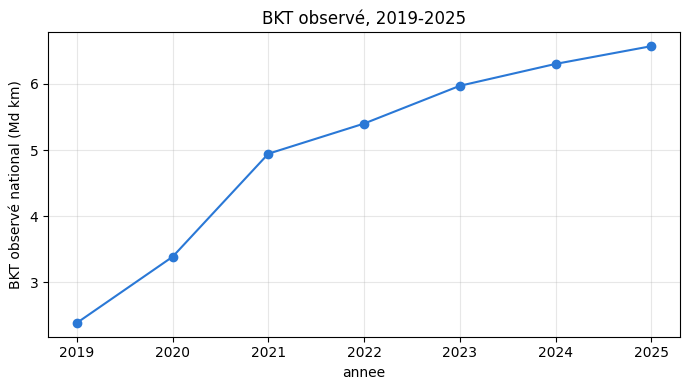

In [5]:
import matplotlib.pyplot as plt

national = communes_bkt_obs.groupby("annee")["bkt_obs"].sum() / 1e9
print("BKT observé national (Md km) :")
print(national.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
national.plot(ax=ax, marker="o", color="#2a78d6")
ax.set_ylabel("BKT observé national (Md km)")
ax.set_title("BKT observé, 2019-2025")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Vérification de cohérence

Contrôle interne : `bkt_obs` ne doit jamais être positif dans une ligne SANS capteur actif cette
année-là (sinon la répartition aurait un problème), jamais négatif nulle part, et la somme des parts
de linéaire d'une commune doit toujours faire 1 (le linéaire n'est ni perdu ni dupliqué).

In [6]:
suspect = communes_bkt_obs[(communes_bkt_obs["n_capteurs_actifs"] == 0) & (communes_bkt_obs["bkt_obs"] > 0)]
negatif = communes_bkt_obs[communes_bkt_obs["bkt_obs"] < 0]
part_totale = communes_bkt_obs.groupby(["annee", "code_commune"])["part_lineaire"].sum()
print(f"lignes sans capteur actif mais BKT observé > 0 : {len(suspect)} (doit être 0)")
print(f"BKT observé négatif : {len(negatif)} (doit être 0)")
print(f"(année, commune) dont la somme des parts de linéaire n'est pas 1 : {(~part_totale.round(9).eq(1.0)).sum()} (doit être 0)")
assert len(suspect) == 0 and len(negatif) == 0 and part_totale.round(9).eq(1.0).all()

lignes sans capteur actif mais BKT observé > 0 : 0 (doit être 0)
BKT observé négatif : 0 (doit être 0)
(année, commune) dont la somme des parts de linéaire n'est pas 1 : 0 (doit être 0)
